In [1]:
import os
import sys
import json
from typing import List, Dict
from sentence_transformers import SentenceTransformer
from sentence_transformers.evaluation import InformationRetrievalEvaluator

print("Thư viện đã được nạp thành công!")

/home/huynh-gia-bao/Documents/NLP-assignment/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Thư viện đã được nạp thành công!


/tmp/ipykernel_621658/1697888224.py:6: DeprecationWarning: Importing from 'sentence_transformers.evaluation' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.evaluation' instead.
  from sentence_transformers.evaluation import InformationRetrievalEvaluator


In [2]:
def load_raw_data(path: str) -> List[Dict]:
    data = []
    if not os.path.exists(path):
        print(f"Cảnh báo: Không tìm thấy file {path}")
        return data
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line))
    return data

# Đường dẫn tới tập dữ liệu
train_path = "../data/training/retriever_train.jsonl"
test_path = "../data/training/retriever_test.jsonl"

train_data = load_raw_data(train_path)
test_data = load_raw_data(test_path)

# Gộp cả 2 tập lại thành một tập duy nhất để đánh giá Baseline
combined_data = train_data + test_data

print(f"- Số lượng mẫu Train: {len(train_data)}")
print(f"- Số lượng mẫu Test: {len(test_data)}")
print(f"Tổng mẫu đưa vào đánh giá Baseline: {len(combined_data)}")

- Số lượng mẫu Train: 270
- Số lượng mẫu Test: 30
Tổng mẫu đưa vào đánh giá Baseline: 300


In [3]:
def prepare_ir_evaluator(data: List[Dict], name: str = 'test') -> InformationRetrievalEvaluator:
    queries = {}
    corpus = {}
    relevant_docs = {}
    
    for i, row in enumerate(data):
        query_id = f"q_{name}_{i}"
        queries[query_id] = row["query"]
        
        # Nạp Positive Chunk
        pos = row["pos"][0] if "pos" in row else (row["positive"][0] if isinstance(row.get("positive"), list) else row["positive"])
        pos_id = f"c_{name}_{i}_pos"
        corpus[pos_id] = pos
        relevant_docs[query_id] = {pos_id}
        
        # Nạp Hard Negatives
        negatives = row.get("neg", []) or row.get("hard_negatives", [])
        for j, neg in enumerate(negatives):
            neg_id = f"c_{name}_{i}_neg_{j}"
            corpus[neg_id] = neg
            
    return InformationRetrievalEvaluator(
        queries=queries,
        corpus=corpus,
        relevant_docs=relevant_docs,
        name=name,
        main_score_function="cosine", 
        accuracy_at_k=[1, 3],
        precision_recall_at_k=[1, 3],
        ndcg_at_k=[10],
        mrr_at_k=[10],
        map_at_k=[100]
    )

evaluator = prepare_ir_evaluator(combined_data, name='test')
print("Evaluator đã được thiết lập với bộ chỉ số đầy đủ.")

Evaluator đã được thiết lập với bộ chỉ số đầy đủ.


In [4]:
model_name = "BAAI/bge-small-en-v1.5"
print(f"Đang nạp mô hình gốc: {model_name}...")

model = SentenceTransformer(model_name)
print("Base Model đã sẵn sàng trong bộ nhớ!")

Đang nạp mô hình gốc: BAAI/bge-small-en-v1.5...


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 15960.12it/s]


Base Model đã sẵn sàng trong bộ nhớ!


In [5]:
output_path = "models/baseline_evaluation_results"
os.makedirs(output_path, exist_ok=True)

print("\nĐANG CHẠY ĐÁNH GIÁ (Vui lòng đợi 1-2 phút)...\n")
results = evaluator(model, output_path=output_path)

# Lọc và in chính xác các chỉ số bạn yêu cầu
target_keys = [
    "test_cosine_accuracy@1",
    "test_cosine_accuracy@3",
    "test_cosine_precision@1",
    "test_cosine_precision@3",
    "test_cosine_recall@1",
    "test_cosine_recall@3",
    "test_cosine_ndcg@10",
    "test_cosine_mrr@10",
    "test_cosine_map@100"
]

print("--- Final Test Set Metrics ---")
for key in target_keys:
    # Xử lý linh hoạt việc thư viện bản mới có thể ẩn đi tiền tố "test_cosine_"
    val = results.get(key, results.get(key.replace("test_cosine_", "test_"), 0.0))
    print(f" - {key}: {val:.4f}")


ĐANG CHẠY ĐÁNH GIÁ (Vui lòng đợi 1-2 phút)...

--- Final Test Set Metrics ---
 - test_cosine_accuracy@1: 0.7533
 - test_cosine_accuracy@3: 0.9667
 - test_cosine_precision@1: 0.7533
 - test_cosine_precision@3: 0.3222
 - test_cosine_recall@1: 0.7533
 - test_cosine_recall@3: 0.9667
 - test_cosine_ndcg@10: 0.8913
 - test_cosine_mrr@10: 0.8586
 - test_cosine_map@100: 0.8591


/tmp/ipykernel_621658/2982365811.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=names, y=values, palette="viridis")


✅ Đồ thị đã được lưu tại: models/baseline_evaluation_results/baseline_metrics_plot.png


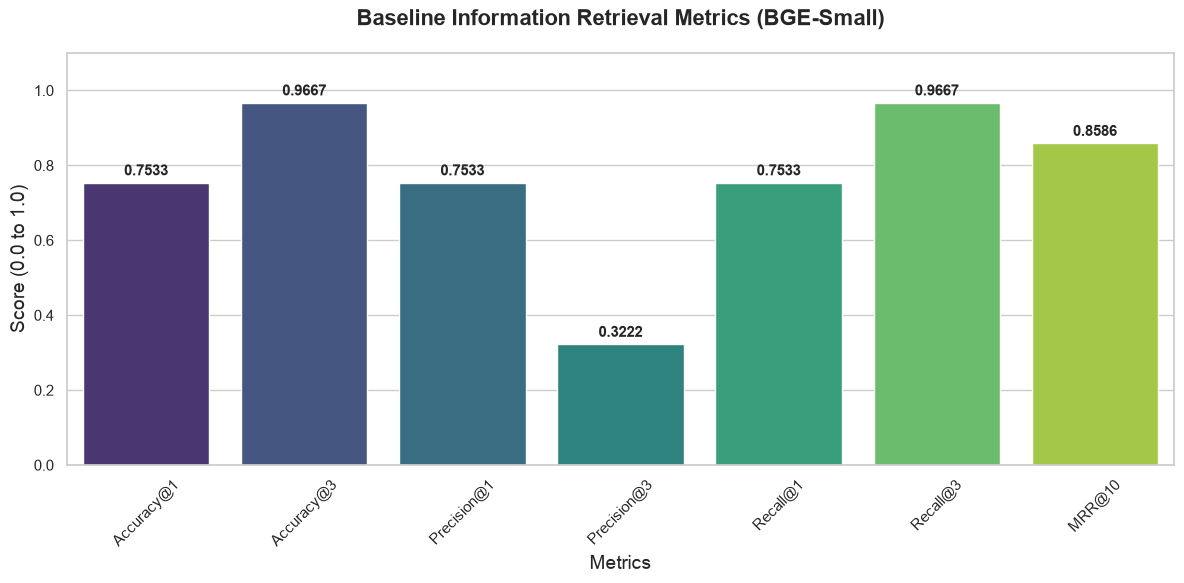

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lấy các chỉ số quan trọng từ biến 'results' ở Cell 5
# Xử lý trường hợp thư viện có hoặc không có tiền tố "test_cosine_"
metrics_to_plot = {
    "Accuracy@1": results.get("test_cosine_accuracy@1", results.get("test_accuracy@1", 0.0)),
    "Accuracy@3": results.get("test_cosine_accuracy@3", results.get("test_accuracy@3", 0.0)),
    "Precision@1": results.get("test_cosine_precision@1", results.get("test_precision@1", 0.0)),
    "Precision@3": results.get("test_cosine_precision@3", results.get("test_precision@3", 0.0)),
    "Recall@1": results.get("test_cosine_recall@1", results.get("test_recall@1", 0.0)),
    "Recall@3": results.get("test_cosine_recall@3", results.get("test_recall@3", 0.0)),
    "MRR@10": results.get("test_cosine_mrr@10", results.get("test_mrr@10", 0.0))
}

names = list(metrics_to_plot.keys())
values = list(metrics_to_plot.values())

# Thiết lập giao diện đồ thị
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Vẽ biểu đồ cột
ax = sns.barplot(x=names, y=values, palette="viridis")

plt.title('Baseline Information Retrieval Metrics (BGE-Small)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Score (0.0 to 1.0)', fontsize=14)
plt.xlabel('Metrics', fontsize=14)
plt.ylim(0, 1.1) # Để dư một chút không gian ở trên cùng cho số liệu
plt.xticks(rotation=45)

# Thêm nhãn số liệu trực tiếp lên đầu mỗi cột
for i, v in enumerate(values):
    ax.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()

# Lưu đồ thị ra file ảnh
plot_path = os.path.join(output_path, "baseline_metrics_plot.png")
plt.savefig(plot_path)
print(f"✅ Đồ thị đã được lưu tại: {plot_path}")

# Hiển thị đồ thị ngay trong Notebook
plt.show()